In [6]:
import random as random
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('sci.mplstyle')

In [60]:
def chuanhoa_chuyendong(a,b,N):
    delta_x= []
    delta_y= []

    for i in range(N):
        delta_x_star = np.random.uniform(a,b)
        delta_y_star = np.random.uniform(a,b)
        L_star = np.sqrt(delta_x_star**2 + delta_y_star**2)

        delta_x_norm = delta_x_star/L_star
        delta_y_norm = delta_y_star/L_star

        delta_x.append(delta_x_norm)
        delta_y.append(delta_y_norm)
    return delta_x, delta_y

def toado_moilan_chuyendong(a,b,N,x0,y0):
    x = []
    y = []
    x.append(x0)
    y.append(y0)

    delta_x, delta_y = chuanhoa_chuyendong(a,b,N)
    for i in range(N):
        x.append(x[i] + delta_x[i])
        y.append(y[i] + delta_y[i])
    
    return x, y

def luu_file_toado(x_list, y_list, filename):
    with open("toado_lan_"+str(filename+1)+".txt", "w", encoding="utf-8") as file:
        file.write(f"# File chua thong tin toa do cua cac diem {filename}\n")
        file.write("#" * 50 + "\n")
        file.write(f"#{'Step':>6s}  {'x':>18s}  {'y':>18s}\n")
        for i in range(len(x_list)):
            file.write(f"{i+1:6d}  {x_list[i]:18.12f}  {y_list[i]:18.12f}\n")

number_of_RDW = 7

a = -2
b =  2
N = 1000
x0 = y0 = 0

for i in range(number_of_RDW):
    x_list, y_list = toado_moilan_chuyendong(a, b, N, x0, y0)
    luu_file_toado(x_list, y_list, i)

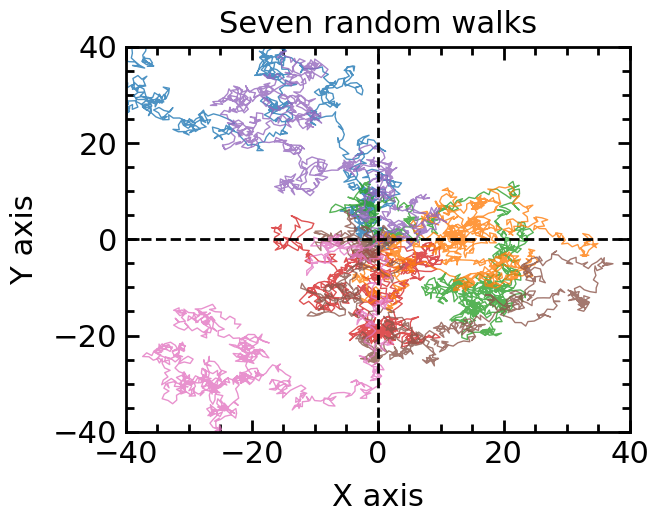

In [79]:
plt.Figure(figsize=(8,8))

for i in range(number_of_RDW):
    step, x, y = np.loadtxt(
        "toado_lan_" + str(i + 1) + ".txt",
        unpack=True,
        comments="#"
    )
    plt.plot(x, y, linewidth=1, label=f"Lan {i+1}", color = f"C{i}", alpha = 0.8)

plt.xlabel("X axis")
plt.ylabel("Y axis")
plt.axvline(0, lw=2, linestyle = "--",color = "black")
plt.axhline(0, lw=2, linestyle = "--",color = "black")

plt.title("Seven random walks")

plt.xlim(-40,40)
plt.ylim(-40,40)
plt.savefig("Hinh_so_1.pdf")
plt.show()